# Echo Top Height Histograms

Plots histograms of MRR (Micro Rain Radar) echo top heights for two sites (Alta and Highland, Utah) across three synoptic weather regimes:
- **S/SWIVT**: South/Southwest Integrated Vapor Transport
- **FR**: Frontal
- **PF**: Northwest Postfrontal

Echo top height is defined as the highest range gate with equivalent reflectivity factor (Ze) exceeding a user-defined threshold (`EchoTop_Ze_max`). Histograms are shown in both MSL and AGL coordinates in a 2×3 panel figure.

**Authors:** Jim Steenburgh, Ashley Evans, Michael Wasserstein  
**Date:** June 2024

## Imports and Configuration

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib
from MRR_functions import open_ds

In [2]:
# -------------------- CONFIGURE PATHS HERE --------------------
# Path to directory containing MRR NetCDF files
# Expected files: highland180_*.nc, highland030_*.nc, alta180_*.nc, alta030_*.nc
data_path = 'Data/MRR/'

# Directory to save output figures
fig_dir = 'Fig/'
# ---------------------------------------------------------------


In [4]:
# Load in data for the event types
highland180_SIVT, highland30_SIVT, alta180_SIVT, alta30_SIVT = open_ds(data_path, 'SIVT')
highland180_FR, highland30_FR, alta180_FR, alta30_FR = open_ds(data_path, 'FR')
highland180_PF, highland30_PF, alta180_PF, alta30_PF = open_ds(data_path, 'PF')

In [5]:
# Ze max for echo-top height calculations
EchoTop_Ze_max = -10.

In [6]:
# Determine heights of highest range gate with Ze > EchoTop_Ze_max
# SIVT 180 m
alta180_SIVT['Echo_heights']=alta180_SIVT.height.where(alta180_SIVT.Ze >= EchoTop_Ze_max)
alta180_SIVT['Echo_heights_ASL']=alta180_SIVT.height_ASL.where(alta180_SIVT.Ze >= EchoTop_Ze_max)
alta180_SIVT['Echo_top_heights']=alta180_SIVT.Echo_heights.max(dim='height_ASL')
alta180_SIVT['Echo_top_heights_ASL']=alta180_SIVT.Echo_heights_ASL.max(dim='height_ASL')
highland180_SIVT['Echo_heights']=highland180_SIVT.height.where(highland180_SIVT.Ze >= EchoTop_Ze_max)
highland180_SIVT['Echo_heights_ASL']=highland180_SIVT.height_ASL.where(highland180_SIVT.Ze >= EchoTop_Ze_max)
highland180_SIVT['Echo_top_heights']=highland180_SIVT.Echo_heights.max(dim='height_ASL')
highland180_SIVT['Echo_top_heights_ASL']=highland180_SIVT.Echo_heights_ASL.max(dim='height_ASL')

# FR 180 m
alta180_FR['Echo_heights']=alta180_FR.height.where(alta180_FR.Ze >= EchoTop_Ze_max)
alta180_FR['Echo_heights_ASL']=alta180_FR.height_ASL.where(alta180_FR.Ze >= EchoTop_Ze_max)
alta180_FR['Echo_top_heights']=alta180_FR.Echo_heights.max(dim='height_ASL')
alta180_FR['Echo_top_heights_ASL']=alta180_FR.Echo_heights_ASL.max(dim='height_ASL')
highland180_FR['Echo_heights']=highland180_FR.height.where(highland180_FR.Ze >= EchoTop_Ze_max)
highland180_FR['Echo_heights_ASL']=highland180_FR.height_ASL.where(highland180_FR.Ze >= EchoTop_Ze_max)
highland180_FR['Echo_top_heights']=highland180_FR.Echo_heights.max(dim='height_ASL')
highland180_FR['Echo_top_heights_ASL']=highland180_FR.Echo_heights_ASL.max(dim='height_ASL')

# PF 180 m
alta180_PF['Echo_heights']=alta180_PF.height.where(alta180_PF.Ze >= EchoTop_Ze_max)
alta180_PF['Echo_heights_ASL']=alta180_PF.height_ASL.where(alta180_PF.Ze >= EchoTop_Ze_max)
alta180_PF['Echo_top_heights']=alta180_PF.Echo_heights.max(dim='height_ASL')
alta180_PF['Echo_top_heights_ASL']=alta180_PF.Echo_heights_ASL.max(dim='height_ASL')
highland180_PF['Echo_heights']=highland180_PF.height.where(highland180_PF.Ze >= EchoTop_Ze_max)
highland180_PF['Echo_heights_ASL']=highland180_PF.height_ASL.where(highland180_PF.Ze >= EchoTop_Ze_max)
highland180_PF['Echo_top_heights']=highland180_PF.Echo_heights.max(dim='height_ASL')
highland180_PF['Echo_top_heights_ASL']=highland180_PF.Echo_heights_ASL.max(dim='height_ASL')

In [7]:
# Get elevations of the two sites
alta_elevation = alta180_FR.MRR_elevation
highland_elevation = highland180_FR.MRR_elevation

In [10]:
# Define the desired bin width
bin_width = 180

# Calculate the range of data 
alta_data_min = alta180_PF.height[0]
alta_data_max = alta180_PF.height[-1]
highland_data_min = highland180_PF.height[0]
highland_data_max = highland180_PF.height[-1]

# Calculate the number of bins based on the desired bin width
alta_num_bins = int((alta_data_max - alta_data_min) / bin_width)
highland_num_bins = int((highland_data_max - highland_data_min) / bin_width)

# Calculate the bin edges for both variables
bar_width=bin_width
alta_bin_edges = np.linspace(alta_data_min + alta180_SIVT.MRR_elevation - bar_width / 2, alta_data_max + alta180_SIVT.MRR_elevation + bar_width / 2, alta_num_bins + 2)
highland_bin_edges = np.linspace(highland_data_min + highland180_SIVT.MRR_elevation - bar_width / 2, highland_data_max + highland180_SIVT.MRR_elevation + bar_width / 2, highland_num_bins + 2)


In [11]:
# Some plot settings
zo_Alta = 5
zo_Highland = 4
fs = 18
props = dict(boxstyle='square', facecolor='white', alpha=0.8, ec="gray")

Alta SIVT q50 ASL: 5202.0 m
Highland SIVT q50 ASL: 5152.0 m
Alta FR q50 ASL: 5202.0 m
Highland FR q50 ASL: 4972.0 m
Alta PF q50 ASL: 3942.0 m
Highland PF q50 ASL: 3352.0 m
Alta SIVT q50 AGL: 2520.0 m
Highland SIVT q50 AGL: 3780.0 m
Alta FR q50 AGL: 2520.0 m
Highland FR q50 AGL: 3600.0 m
Alta PF q50 AGL: 1260.0 m
Highland PF q50 AGL: 1980.0 m


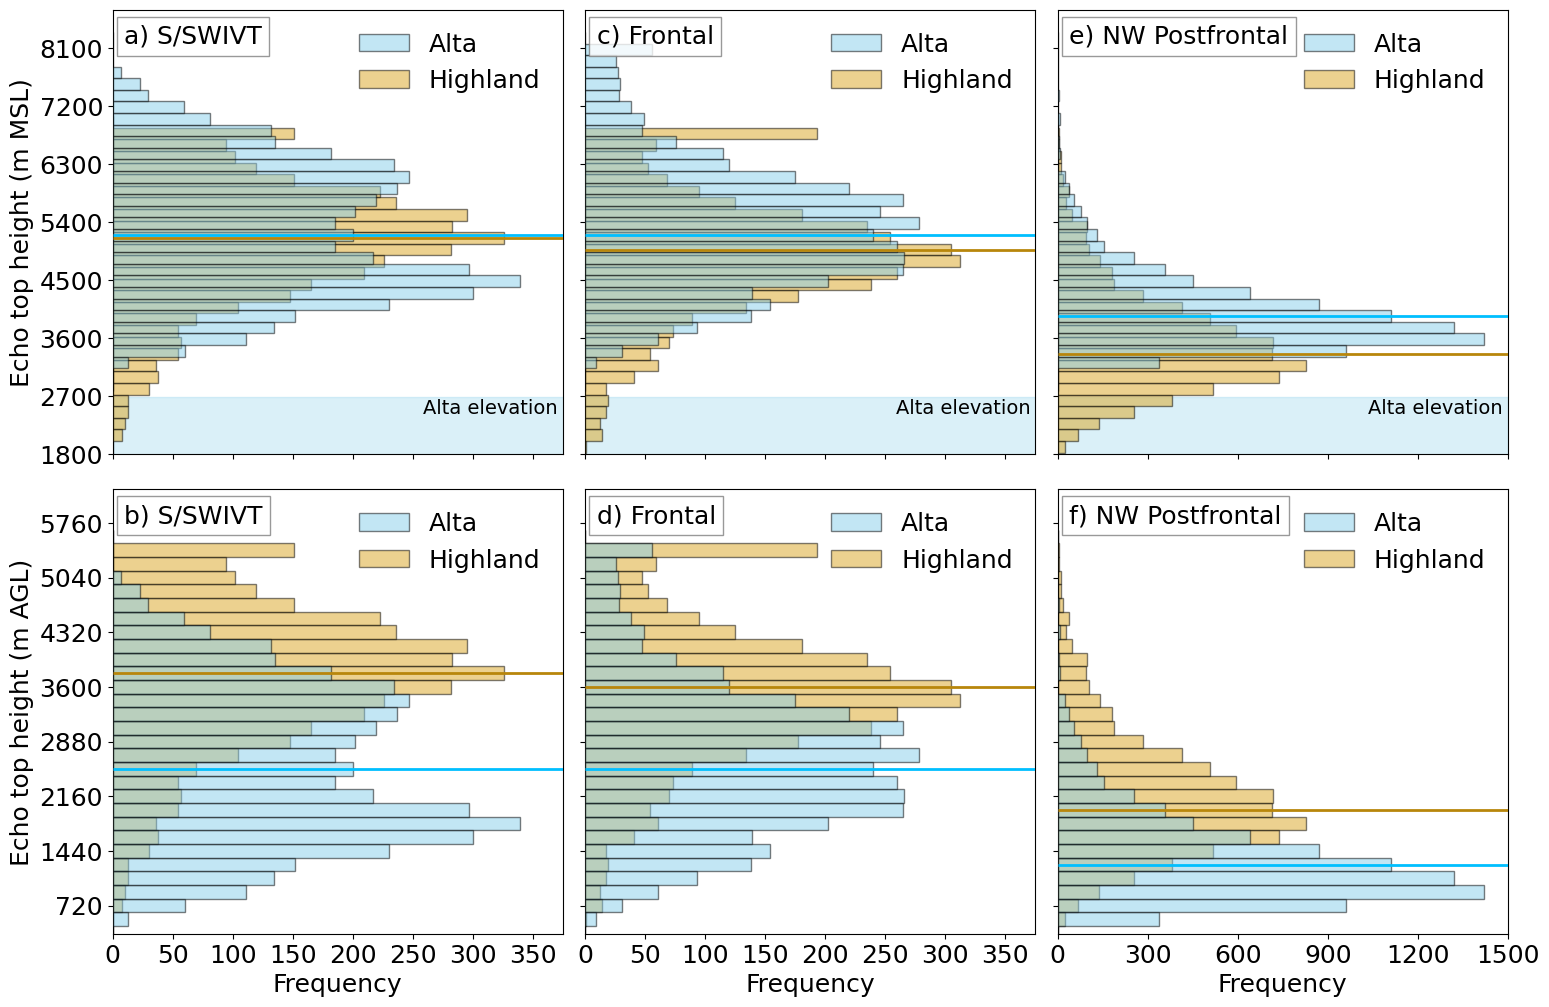

In [ ]:
# Plot histogram of 180-m echo-top heights (MSL top row, AGL bottom row)
fig, ((ax1, ax2, ax3), (ax1_, ax2_, ax3_)) = plt.subplots(
    2, 3, figsize=(18, 12), facecolor='white', edgecolor='k',
    sharex='col', sharey='row'
)

# ── MSL (top row) ────────────────────────────────────────────────────────────

###################### S/SWIVT ######################
ax1.hist(alta180_SIVT.Echo_top_heights_ASL.values.flatten(),
         bins=alta_bin_edges, alpha=0.5, edgecolor='k', label='Alta',
         color='skyblue', zorder=zo_Alta, orientation='horizontal')
ax1.hist(highland180_SIVT.Echo_top_heights_ASL.values.flatten(),
         bins=highland_bin_edges, alpha=0.5, edgecolor='k', label='Highland',
         color='goldenrod', zorder=zo_Highland, orientation='horizontal')

# Add labels, ticks, and limits
ax1.set_ylabel('Echo top height (m MSL)', fontsize=fs)
ax1.set_yticks(np.arange(1800.0, 8501, 900),
               labels=np.arange(1800.0, 8501, 900).astype(int), fontsize=fs)
ax1.set_xticks(np.arange(0, 351, 50), labels=np.arange(0, 351, 50), fontsize=fs)
ax1.set_xlim(0, 375)
ax1.set_ylim(1800,)

# Calculate and Add median lines and legend
alta180_q50 = np.nanpercentile(alta180_SIVT['Echo_top_heights_ASL'].values, 50)
highland180_q50 = np.nanpercentile(highland180_SIVT['Echo_top_heights_ASL'].values, 50)
print(f'Alta SIVT q50 ASL: {alta180_q50} m')
print(f'Highland SIVT q50 ASL: {highland180_q50} m')
ax1.hlines(alta180_q50, 0, 400, zorder=19, colors='deepskyblue', linewidth=2)
ax1.hlines(highland180_q50, 0, 400, zorder=19, colors='darkgoldenrod', linewidth=2)
ax1.legend(loc='upper right', fontsize=fs, edgecolor='none')

###################### Frontal ######################
ax2.hist(alta180_FR.Echo_top_heights_ASL.values.flatten(),
         bins=alta_bin_edges, alpha=0.5, edgecolor='k', label='Alta',
         color='skyblue', zorder=zo_Alta, orientation='horizontal')
ax2.hist(highland180_FR.Echo_top_heights_ASL.values.flatten(),
         bins=highland_bin_edges, alpha=0.5, edgecolor='k', label='Highland',
         color='goldenrod', zorder=zo_Highland, orientation='horizontal')

# Add labels, ticks, and limits
ax2.set_yticks(np.arange(1800.0, 8501, 900),
               labels=np.arange(1800.0, 8501, 900).astype(int), fontsize=fs)
ax2.set_xticks(np.arange(0, 351, 50), labels=np.arange(0, 351, 50), fontsize=fs)
ax2.set_xlim(0, 375)
ax2.set_ylim(1800,)

# Calculate and Add median lines and legend
alta180_q50 = np.nanpercentile(alta180_FR['Echo_top_heights_ASL'].values, 50)
highland180_q50 = np.nanpercentile(highland180_FR['Echo_top_heights_ASL'].values, 50)
print(f'Alta FR q50 ASL: {alta180_q50} m')
print(f'Highland FR q50 ASL: {highland180_q50} m')
ax2.hlines(alta180_q50, 0, 400, zorder=19, colors='deepskyblue', linewidth=2)
ax2.hlines(highland180_q50, 0, 400, zorder=19, colors='darkgoldenrod', linewidth=2)
ax2.legend(loc='upper right', fontsize=fs, edgecolor='none')

###################### NW Postfrontal ######################
ax3.hist(alta180_PF.Echo_top_heights_ASL.values.flatten(),
         bins=alta_bin_edges, alpha=0.5, edgecolor='k', label='Alta',
         color='skyblue', zorder=zo_Alta, orientation='horizontal')
ax3.hist(highland180_PF.Echo_top_heights_ASL.values.flatten(),
         bins=highland_bin_edges, alpha=0.5, edgecolor='k', label='Highland',
         color='goldenrod', zorder=zo_Highland, orientation='horizontal')
ax3.set_yticks(np.arange(1800.0, 8501, 900),
               labels=np.arange(1800.0, 8501, 900).astype(int), fontsize=fs)

# Add labels, ticks, and limits
ax3.set_xticks(np.arange(0, 1501, 200), labels=np.arange(0, 1501, 200), fontsize=fs)
ax3.set_xlim(0, 1500)
ax3.set_ylim(1800,)

# Calculate and Add median lines and legend
alta180_q50 = np.nanpercentile(alta180_PF['Echo_top_heights_ASL'].values, 50)
highland180_q50 = np.nanpercentile(highland180_PF['Echo_top_heights_ASL'].values, 50)
print(f'Alta PF q50 ASL: {alta180_q50} m')
print(f'Highland PF q50 ASL: {highland180_q50} m')
ax3.hlines(alta180_q50, 0, 1800, zorder=19, colors='deepskyblue', linewidth=2)
ax3.hlines(highland180_q50, 0, 1800, zorder=19, colors='darkgoldenrod', linewidth=2)
ax3.legend(loc='upper right', fontsize=fs, edgecolor='none')

# ── AGL (bottom row) ─────────────────────────────────────────────────────────

###################### S/SWIVT ######################
ax1_.hist(alta180_SIVT.Echo_top_heights.values.flatten(),
          bins=alta_bin_edges - alta_elevation, alpha=0.5, edgecolor='k',
          label='Alta', color='skyblue', zorder=zo_Alta, orientation='horizontal')
ax1_.hist(highland180_SIVT.Echo_top_heights.values.flatten(),
          bins=highland_bin_edges - highland_elevation, alpha=0.5, edgecolor='k',
          label='Highland', color='goldenrod', zorder=zo_Highland, orientation='horizontal')

# Add labels, ticks, and limits
ax1_.set_ylabel('Echo top height (m AGL)', fontsize=fs)
ax1_.set_yticks(np.arange(0, 8001, 720), labels=np.arange(0, 8001, 720), fontsize=fs)
ax1_.set_xticks(np.arange(0, 351, 50), labels=np.arange(0, 351, 50), fontsize=fs)
ax1_.set_xlim(0, 375)
ax1_.set_ylim(350, 6200)

# Calculate and Add median lines and legend
alta180_q50 = np.nanpercentile(alta180_SIVT['Echo_top_heights'].values, 50)
highland180_q50 = np.nanpercentile(highland180_SIVT['Echo_top_heights'].values, 50)
print(f'Alta SIVT q50 AGL: {alta180_q50} m')
print(f'Highland SIVT q50 AGL: {highland180_q50} m')
ax1_.hlines(alta180_q50, 0, 400, zorder=19, colors='deepskyblue', linewidth=2)
ax1_.hlines(highland180_q50, 0, 400, zorder=19, colors='darkgoldenrod', linewidth=2)
ax1_.legend(loc='upper right', fontsize=fs, edgecolor='none')

###################### Frontal ######################
ax2_.hist(alta180_FR.Echo_top_heights.values.flatten(),
          bins=alta_bin_edges - alta_elevation, alpha=0.5, edgecolor='k',
          label='Alta', color='skyblue', zorder=zo_Alta, orientation='horizontal')
ax2_.hist(highland180_FR.Echo_top_heights.values.flatten(),
          bins=highland_bin_edges - highland_elevation, alpha=0.5, edgecolor='k',
          label='Highland', color='goldenrod', zorder=zo_Highland, orientation='horizontal')

# Add labels, ticks, and limits
ax2_.set_yticks(np.arange(0, 8001, 720), labels=np.arange(0, 8001, 720), fontsize=fs)
ax2_.set_xticks(np.arange(0, 351, 50), labels=np.arange(0, 351, 50), fontsize=fs)
ax2_.set_xlim(0, 375)
ax2_.set_ylim(350, 6200)

# Calculate and Add median lines and legend
alta180_q50 = np.nanpercentile(alta180_FR['Echo_top_heights'].values, 50)
highland180_q50 = np.nanpercentile(highland180_FR['Echo_top_heights'].values, 50)
print(f'Alta FR q50 AGL: {alta180_q50} m')
print(f'Highland FR q50 AGL: {highland180_q50} m')
ax2_.hlines(alta180_q50, 0, 400, zorder=19, colors='deepskyblue', linewidth=2)
ax2_.hlines(highland180_q50, 0, 400, zorder=19, colors='darkgoldenrod', linewidth=2)
ax2_.legend(loc='upper right', fontsize=fs, edgecolor='none')

###################### NW Postfrontal ######################
ax3_.hist(alta180_PF.Echo_top_heights.values.flatten(),
          bins=alta_bin_edges - alta_elevation, alpha=0.5, edgecolor='k',
          label='Alta', color='skyblue', zorder=zo_Alta, orientation='horizontal')
ax3_.hist(highland180_PF.Echo_top_heights.values.flatten(),
          bins=highland_bin_edges - highland_elevation, alpha=0.5, edgecolor='k',
          label='Highland', color='goldenrod', zorder=zo_Highland, orientation='horizontal')

# Add labels, ticks, and limits
ax3_.set_yticks(np.arange(0, 8001, 720), labels=np.arange(0, 8001, 720), fontsize=fs)
ax3_.set_xticks(np.arange(0, 1501, 300), labels=np.arange(0, 1501, 300), fontsize=fs)
ax3_.set_xlim(0, 1500)
ax3_.set_ylim(350, 6200)

# Calculate and Add median lines and legend
alta180_q50 = np.nanpercentile(alta180_PF['Echo_top_heights'].values, 50)
highland180_q50 = np.nanpercentile(highland180_PF['Echo_top_heights'].values, 50)
print(f'Alta PF q50 AGL: {alta180_q50} m')
print(f'Highland PF q50 AGL: {highland180_q50} m')
ax3_.hlines(alta180_q50, 0, 1800, zorder=19, colors='deepskyblue', linewidth=2)
ax3_.hlines(highland180_q50, 0, 1800, zorder=19, colors='darkgoldenrod', linewidth=2)
ax3_.legend(loc='upper right', fontsize=fs, edgecolor='none')

# ── Panel labels ─────────────────────────────────────────────────────────────
ax1.text(0.025, 0.925, 'a) S/SWIVT', transform=ax1.transAxes, fontsize=fs, bbox=props, zorder=20)
ax2.text(0.025, 0.925, 'c) Frontal', transform=ax2.transAxes, fontsize=fs, bbox=props, zorder=20)
ax3.text(0.025, 0.925, 'e) NW Postfrontal', transform=ax3.transAxes, fontsize=fs, bbox=props, zorder=20)
ax1_.text(0.025, 0.925, 'b) S/SWIVT', transform=ax1_.transAxes, fontsize=fs, bbox=props, zorder=20)
ax2_.text(0.025, 0.925, 'd) Frontal', transform=ax2_.transAxes, fontsize=fs, bbox=props, zorder=20)
ax3_.text(0.025, 0.925, 'f) NW Postfrontal', transform=ax3_.transAxes, fontsize=fs, bbox=props, zorder=20)

# ── Axis labels ───────────────────────────────────────────────────────────────
ax1_.set_xlabel('Frequency', fontsize=fs)
ax2_.set_xlabel('Frequency', fontsize=fs)
ax3_.set_xlabel('Frequency', fontsize=fs)

# ── Alta elevation shading (for MSL panels only) ──────────────────────────────────
ax1.fill_between(x=[0, 500], y1=alta_elevation, y2=0, color='skyblue', zorder=1, alpha=0.3)
ax2.fill_between(x=[0, 500], y1=alta_elevation, y2=0, color='skyblue', zorder=1, alpha=0.3)
ax3.fill_between(x=[0, 1501], y1=alta_elevation, y2=0, color='skyblue', zorder=1, alpha=0.3)
ax1.text(0.69, 0.09, 'Alta elevation', transform=ax1.transAxes, color='black', zorder=2, alpha=1, fontsize=14)
ax2.text(0.69, 0.09, 'Alta elevation', transform=ax2.transAxes, color='black', zorder=2, alpha=1, fontsize=14)
ax3.text(0.69, 0.09, 'Alta elevation', transform=ax3.transAxes, color='black', zorder=2, alpha=1, fontsize=14)

# Tighten up figure and save
plt.subplots_adjust(hspace=0.08, wspace=0.05)
plt.savefig(fig_dir + 'Hist_echo_top_height_all_periods_ASL_AGL_6_panel.png', dpi=300, bbox_inches='tight')
plt.show()
